# Feature Correlation Analysis - Hierarchical Clustering

This notebook analyzes correlations between all 88 features in the dataset
and identifies correlation groups using hierarchical clustering.

### Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import networkx as nx
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')

### Load Dataset and Initial Exploration

In [2]:
# Load the dataset
data_file = r"C:\Users\AGFirass\Documents\GitHub\Transformer-Based-DDoS-Detection\data\subset\01-12\flow-level\combined_subset_12k.parquet"

print("Loading dataset...")
df = pd.read_parquet(data_file)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts().sort_index())

Loading dataset...
Dataset shape: (144000, 88)
Columns: ['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length 

### Prepare Features and Labels

In [3]:
# Separate features from labels
feature_columns = [col for col in df.columns if col != 'Label']
print(f"\nTotal features: {len(feature_columns)}")
print(f"First 10 features: {feature_columns[:10]}")

# Create feature-only DataFrame
X = df[feature_columns].copy()
y = df['Label'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Data types:\n{X.dtypes.value_counts()}")


Total features: 87
First 10 features: ['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets']

Feature matrix shape: (144000, 87)
Data types:
float64    45
int64      37
object      5
Name: count, dtype: int64


### Data Quality Assessment

In [4]:
# Check for missing values and data quality
print("Data Quality Check:")
print(f"Missing values per column:")
missing_values = X.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")

print(f"\nInfinite values check:")
inf_values = np.isinf(X.select_dtypes(include=[np.number])).sum()
if inf_values.sum() > 0:
    print(inf_values[inf_values > 0])
else:
    print("No infinite values found!")

Data Quality Check:
Missing values per column:
Flow Bytes/s    2477
dtype: int64

Infinite values check:
Flow Bytes/s      1678
Flow Packets/s    4155
dtype: int64


### Filter Numeric Features

In [6]:
# Identify numeric columns only
print("Identifying numeric features...")
numeric_columns = []
non_numeric_columns = []

for col in feature_columns:
    try:
        # Try to convert to numeric
        pd.to_numeric(X[col], errors='raise')
        numeric_columns.append(col)
    except (ValueError, TypeError):
        non_numeric_columns.append(col)

print(f"Total original features: {len(feature_columns)}")
print(f"Numeric features: {len(numeric_columns)}")
print(f"Non-numeric features: {len(non_numeric_columns)}")

if len(non_numeric_columns) > 0:
    print(f"\nNon-numeric features found:")
    for col in non_numeric_columns[:10]:  # Show first 10
        print(f"  - {col}: {X[col].dtype}")
    if len(non_numeric_columns) > 10:
        print(f"  ... and {len(non_numeric_columns) - 10} more")

# Keep only numeric features
X_numeric = X[numeric_columns].copy()
print(f"\nFiltered to numeric features shape: {X_numeric.shape}")

Identifying numeric features...
Total original features: 87
Numeric features: 82
Non-numeric features: 5

Non-numeric features found:
  - Flow ID: object
  - Source IP: object
  - Destination IP: object
  - Timestamp: object
  - SimillarHTTP: object

Filtered to numeric features shape: (144000, 82)


### Data Cleaning

In [7]:
# Handle any data issues in numeric data
# Replace infinite values with NaN, then with column median
X_clean = X_numeric.copy()
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

# Check for remaining issues
print("Data quality after filtering to numeric:")
print(f"Missing values: {X_clean.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X_clean).sum().sum()}")

# Fill missing values with median
if X_clean.isnull().sum().sum() > 0:
    print("Filling missing values with column medians...")
    X_clean = X_clean.fillna(X_clean.median())

print(f"Final cleaned data shape: {X_clean.shape}")
print(f"Data types: {X_clean.dtypes.value_counts()}")

Data quality after filtering to numeric:
Missing values: 8310
Infinite values: 0
Filling missing values with column medians...
Final cleaned data shape: (144000, 82)
Data types: float64    45
int64      37
Name: count, dtype: int64


### Calculate Correlation Matrix

In [8]:
# Calculate correlation matrix
print("Calculating correlation matrix...")
correlation_matrix = X_clean.corr()

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"Correlation range: [{correlation_matrix.min().min():.3f}, {correlation_matrix.max().max():.3f}]")

# Update feature_columns to only include numeric features
feature_columns = numeric_columns
print(f"Updated feature count for analysis: {len(feature_columns)}")

Calculating correlation matrix...
Correlation matrix shape: (82, 82)
Correlation range: [-0.850, 1.000]
Updated feature count for analysis: 82


### Visualize Correlation Heatmap

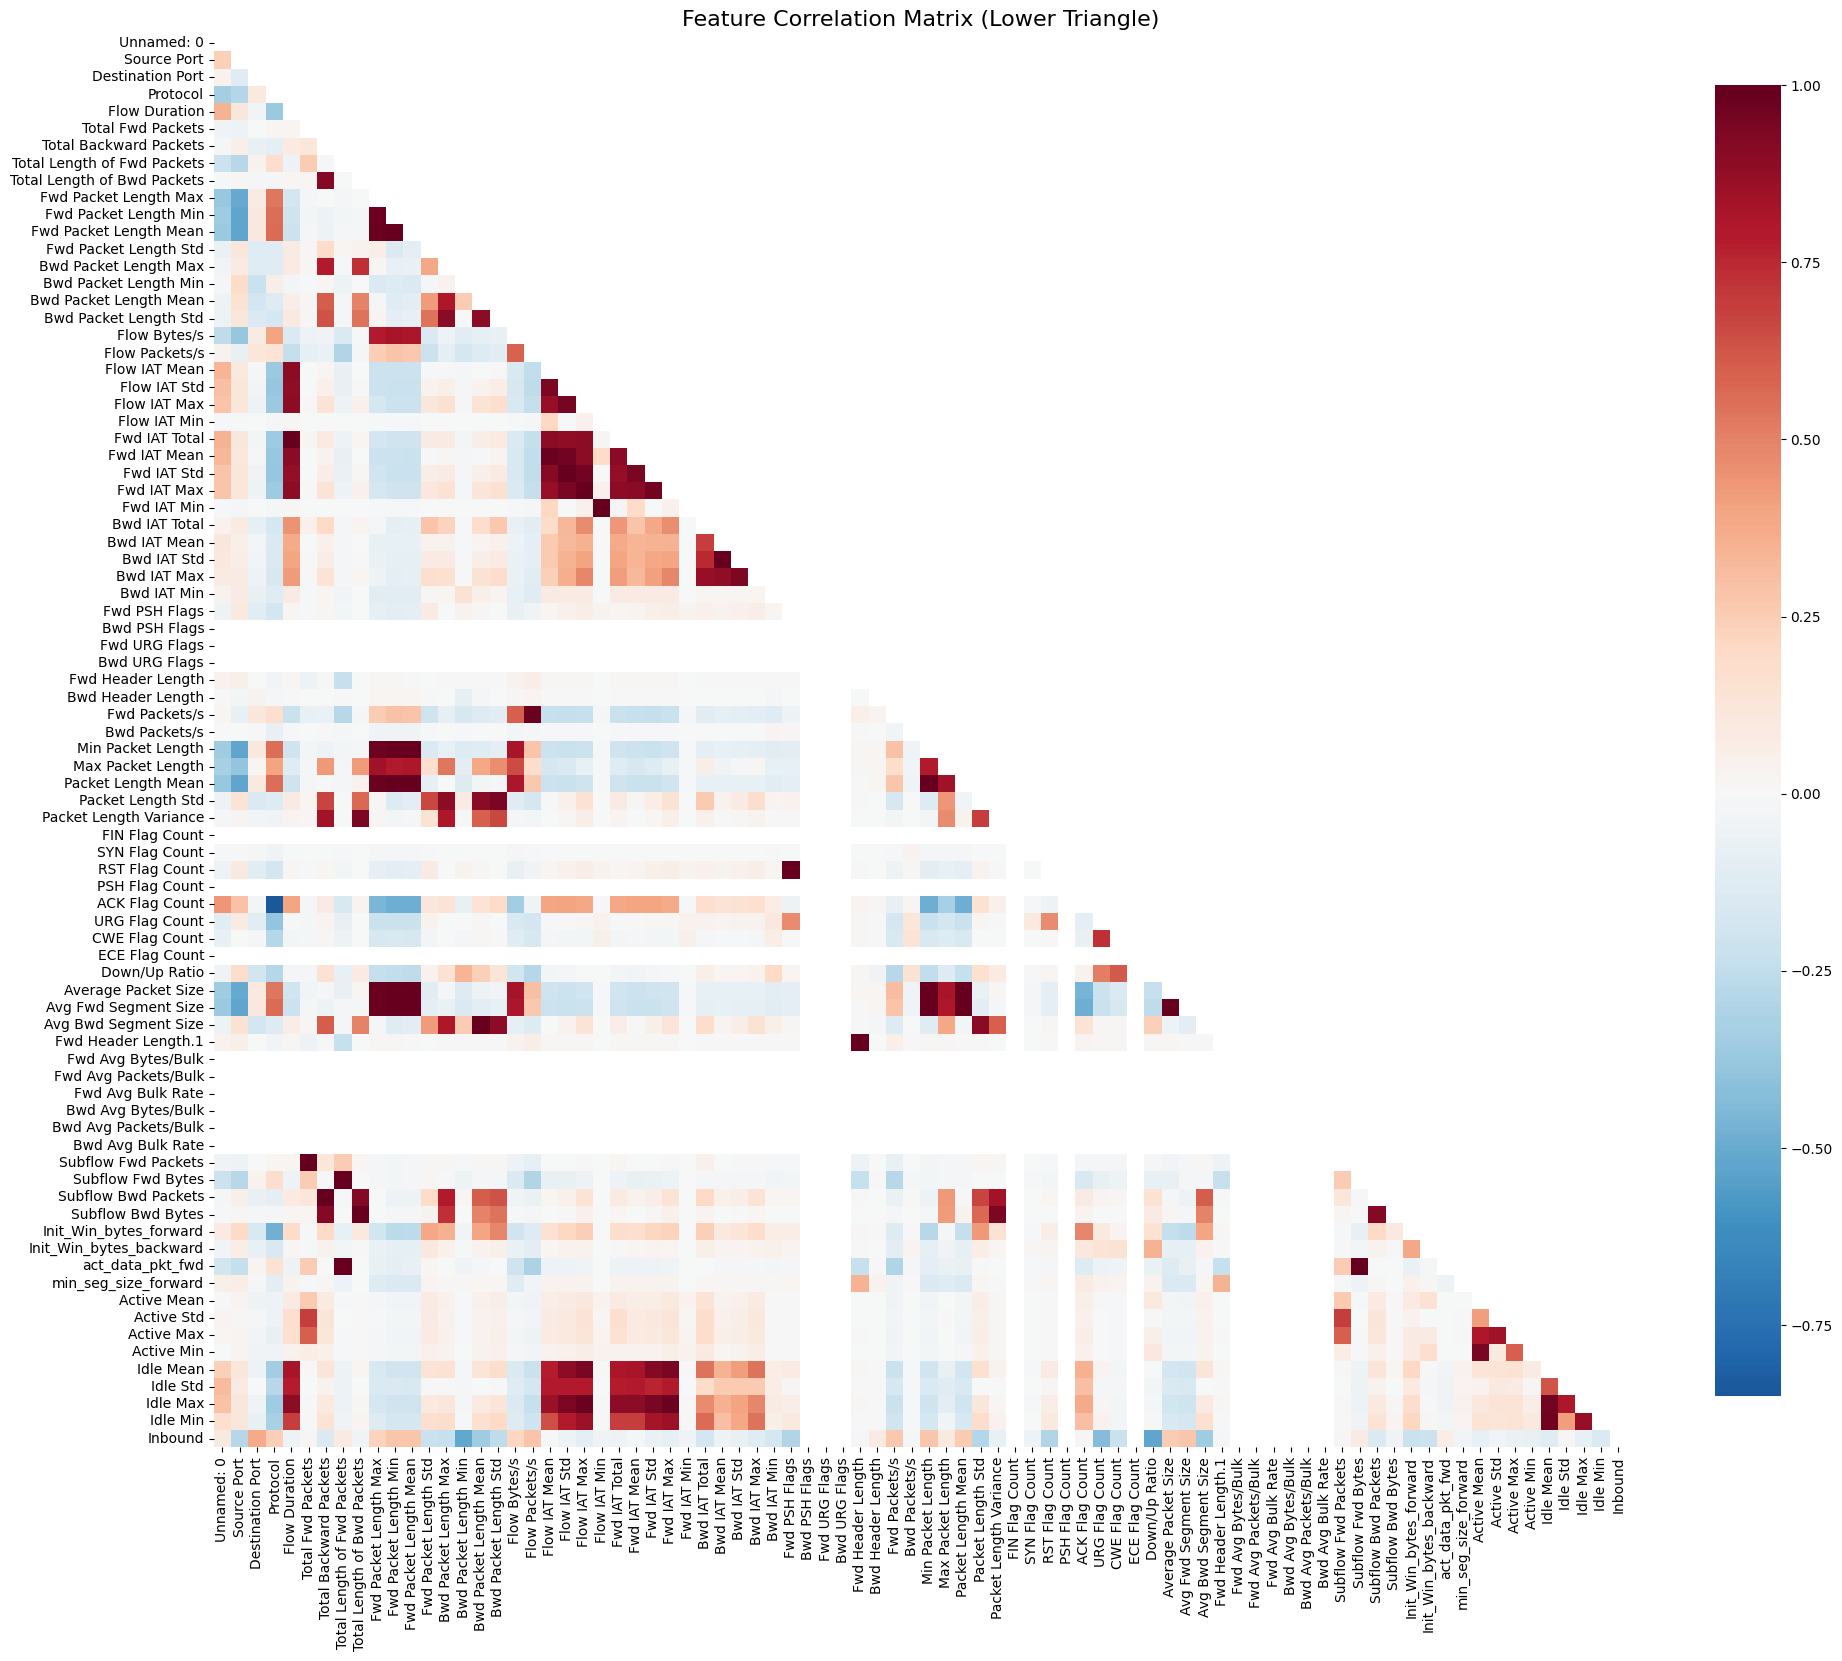

In [9]:
# Visualize correlation matrix heatmap
plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=False,
            cmap='RdBu_r',
            center=0,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Find Highly Correlated Pairs

In [11]:
# Find highly correlated pairs (threshold > 0.85)
high_corr_pairs = []
correlation_threshold = 0.85

print(f"\nFinding feature pairs with correlation > {correlation_threshold}...")

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > correlation_threshold:
            high_corr_pairs.append({
                'feature_1': correlation_matrix.columns[i],
                'feature_2': correlation_matrix.columns[j],
                'correlation': corr_value,
                'abs_correlation': abs(corr_value)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('abs_correlation', ascending=False)

print(f"Found {len(high_corr_pairs)} highly correlated pairs")
if len(high_corr_pairs) > 0:
    print(f"\nTop 10 most correlated pairs:")
    print(high_corr_df.head(10))
else:
    print("No highly correlated pairs found!")


Finding feature pairs with correlation > 0.85...
Found 96 highly correlated pairs

Top 10 most correlated pairs:
                      feature_1             feature_2  correlation  \
37       Bwd Packet Length Mean  Avg Bwd Segment Size     1.000000   
11       Total Backward Packets   Subflow Bwd Packets     1.000000   
9             Total Fwd Packets   Subflow Fwd Packets     1.000000   
13  Total Length of Fwd Packets     Subflow Fwd Bytes     1.000000   
81            Fwd Header Length   Fwd Header Length.1     1.000000   
80                Fwd PSH Flags        RST Flag Count     1.000000   
32       Fwd Packet Length Mean  Avg Fwd Segment Size     1.000000   
17  Total Length of Bwd Packets     Subflow Bwd Bytes     1.000000   
25        Fwd Packet Length Min     Min Packet Length     0.999864   
62                 Flow IAT Min           Fwd IAT Min     0.999624   

    abs_correlation  
37         1.000000  
11         1.000000  
9          1.000000  
13         1.000000  
81   

### Hierarchical Clustering

In [14]:
# Hierarchical clustering to find correlation groups
print("\nPerforming hierarchical clustering...")

# Check for NaN values in correlation matrix
nan_count = correlation_matrix.isnull().sum().sum()
print(f"NaN values in correlation matrix: {nan_count}")

if nan_count > 0:
    print("Handling NaN correlations...")
    # Fill NaN correlations with 0 (no correlation)
    correlation_matrix_clean = correlation_matrix.fillna(0)
else:
    correlation_matrix_clean = correlation_matrix.copy()

# Convert correlation to distance (1 - |correlation|)
distance_matrix = 1 - abs(correlation_matrix_clean)

# Ensure all distances are non-negative (fix floating point precision issues)
distance_matrix = np.maximum(distance_matrix, 0)

# Check for non-finite values in distance matrix
non_finite_count = (~np.isfinite(distance_matrix)).sum().sum()
print(f"Non-finite values in distance matrix: {non_finite_count}")

if non_finite_count > 0:
    print("Handling non-finite distance values...")
    # Replace non-finite values with maximum distance (1.0)
    distance_matrix = distance_matrix.fillna(1.0)
    distance_matrix = np.where(np.isfinite(distance_matrix), distance_matrix, 1.0)

# Convert to condensed distance matrix for linkage
condensed_distance = squareform(distance_matrix, checks=False)

# Ensure condensed distances are non-negative
condensed_distance = np.maximum(condensed_distance, 0)

# Check condensed distance matrix
print(f"Condensed distance matrix shape: {condensed_distance.shape}")
print(f"Finite values in condensed matrix: {np.isfinite(condensed_distance).sum()} / {len(condensed_distance)}")
print(f"Distance range: [{condensed_distance.min():.6f}, {condensed_distance.max():.6f}]")

# Perform hierarchical clustering with error handling
try:
    linkage_matrix = linkage(condensed_distance, method='average')

    # Check linkage matrix for issues
    print(f"Linkage matrix shape: {linkage_matrix.shape}")
    print(f"Distance range in linkage: [{linkage_matrix[:, 2].min():.6f}, {linkage_matrix[:, 2].max():.6f}]")

    # Ensure linkage distances are non-negative (fix any remaining precision issues)
    linkage_matrix[:, 2] = np.maximum(linkage_matrix[:, 2], 0)

    # Get clusters with threshold corresponding to correlation > 0.85
    # Distance threshold = 1 - 0.85 = 0.15
    distance_threshold = 1 - correlation_threshold
    clusters = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')

    print(f"Number of clusters found: {max(clusters)}")
    print(f"Clustering completed successfully!")

except Exception as e:
    print(f"Error in clustering: {e}")
    # Fallback: use simple thresholding approach
    print("Using fallback clustering approach...")

    # Create clusters based on correlation threshold directly
    from sklearn.cluster import AgglomerativeClustering

    # Use precomputed distance matrix
    clusterer = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=distance_threshold,
        affinity='precomputed',
        linkage='average'
    )

    clusters = clusterer.fit_predict(distance_matrix)
    clusters = clusters + 1  # Make clusters 1-indexed to match fcluster

    print(f"Number of clusters found (fallback): {max(clusters)}")


Performing hierarchical clustering...
NaN values in correlation matrix: 1824
Handling NaN correlations...
Non-finite values in distance matrix: 0
Condensed distance matrix shape: (3321,)
Finite values in condensed matrix: 3321 / 3321
Distance range: [0.000000, 1.000000]
Linkage matrix shape: (81, 4)
Distance range in linkage: [0.000000, 1.000000]
Number of clusters found: 49
Clustering completed successfully!


### Analyze Clustering Results

In [15]:
# Analyze clusters and create correlation groups
cluster_dict = defaultdict(list)
for idx, cluster_id in enumerate(clusters):
    feature_name = correlation_matrix.index[idx]
    cluster_dict[cluster_id].append(feature_name)

# Filter out single-feature clusters (no correlations)
correlation_groups = {}
singleton_features = []

for cluster_id, features in cluster_dict.items():
    if len(features) > 1:
        correlation_groups[f"Group_{cluster_id}"] = features
    else:
        singleton_features.extend(features)

print(f"\nCorrelation Groups Analysis:")
print(f"Total correlation groups: {len(correlation_groups)}")
print(f"Features in correlation groups: {sum(len(features) for features in correlation_groups.values())}")
print(f"Singleton features (no high correlations): {len(singleton_features)}")


Correlation Groups Analysis:
Total correlation groups: 14
Features in correlation groups: 47
Singleton features (no high correlations): 35


### Detailed Group Analysis

In [18]:
# Display correlation groups
print(f"\n{'='*80}")
print("CORRELATION GROUPS DETAILED ANALYSIS")
print(f"{'='*80}")

groups_analysis = []

for group_name, features in correlation_groups.items():
    print(f"\n  {group_name.upper()} ({len(features)} features):")

    # Calculate internal correlations
    group_corr_matrix = correlation_matrix.loc[features, features]

    # Get average correlation within group
    upper_triangle = np.triu(group_corr_matrix.values, k=1)
    non_zero_corr = upper_triangle[upper_triangle != 0]
    avg_correlation = np.mean(np.abs(non_zero_corr)) if len(non_zero_corr) > 0 else 0

    # Find min and max correlations in group
    min_correlation = np.min(np.abs(non_zero_corr)) if len(non_zero_corr) > 0 else 0
    max_correlation = np.max(np.abs(non_zero_corr)) if len(non_zero_corr) > 0 else 0

    print(f"      Internal correlations - Avg: {avg_correlation:.3f}, Range: [{min_correlation:.3f}, {max_correlation:.3f}]")
    print(f"      Features:")

    for i, feature in enumerate(features, 1):
        print(f"      {i}. {feature}")

    # Store group analysis
    groups_analysis.append({
        'group_name': group_name,
        'feature_count': len(features),
        'features': features,
        'avg_correlation': avg_correlation,
        'min_correlation': min_correlation,
        'max_correlation': max_correlation
    })


CORRELATION GROUPS DETAILED ANALYSIS

  GROUP_25 (2 features):
      Internal correlations - Avg: 0.850, Range: [0.850, 0.850]
      Features:
      1. Protocol
      2. ACK Flag Count

  GROUP_19 (9 features):
      Internal correlations - Avg: 0.920, Range: [0.861, 0.999]
      Features:
      1. Flow Duration
      2. Flow IAT Mean
      3. Flow IAT Std
      4. Flow IAT Max
      5. Fwd IAT Total
      6. Fwd IAT Mean
      7. Fwd IAT Std
      8. Fwd IAT Max
      9. Idle Max

  GROUP_7 (2 features):
      Internal correlations - Avg: 1.000, Range: [1.000, 1.000]
      Features:
      1. Total Fwd Packets
      2. Subflow Fwd Packets

  GROUP_10 (5 features):
      Internal correlations - Avg: 0.922, Range: [0.839, 1.000]
      Features:
      1. Total Backward Packets
      2. Total Length of Bwd Packets
      3. Packet Length Variance
      4. Subflow Bwd Packets
      5. Subflow Bwd Bytes

  GROUP_14 (3 features):
      Internal correlations - Avg: 0.998, Range: [0.998, 1.000]

### Create Network Graph

In [19]:
# Create network graph visualization of correlations
print(f"\n  Creating correlation network graph...")

# Create correlation graph using NetworkX
G = nx.Graph()

# Add all features as nodes
for feature in feature_columns:
    G.add_node(feature)

# Add edges for highly correlated features
for _, row in high_corr_df.iterrows():
    G.add_edge(row['feature_1'], row['feature_2'],
               weight=row['abs_correlation'],
               correlation=row['correlation'])

# Find connected components (these are our correlation groups)
connected_components = list(nx.connected_components(G))

print(f"Network analysis:")
print(f"   Nodes (features): {G.number_of_nodes()}")
print(f"   Edges (correlations > {correlation_threshold}): {G.number_of_edges()}")
print(f"   Connected components: {len(connected_components)}")


  Creating correlation network graph...
Network analysis:
   Nodes (features): 82
   Edges (correlations > 0.85): 96
   Connected components: 46


### Visualize Network Graph

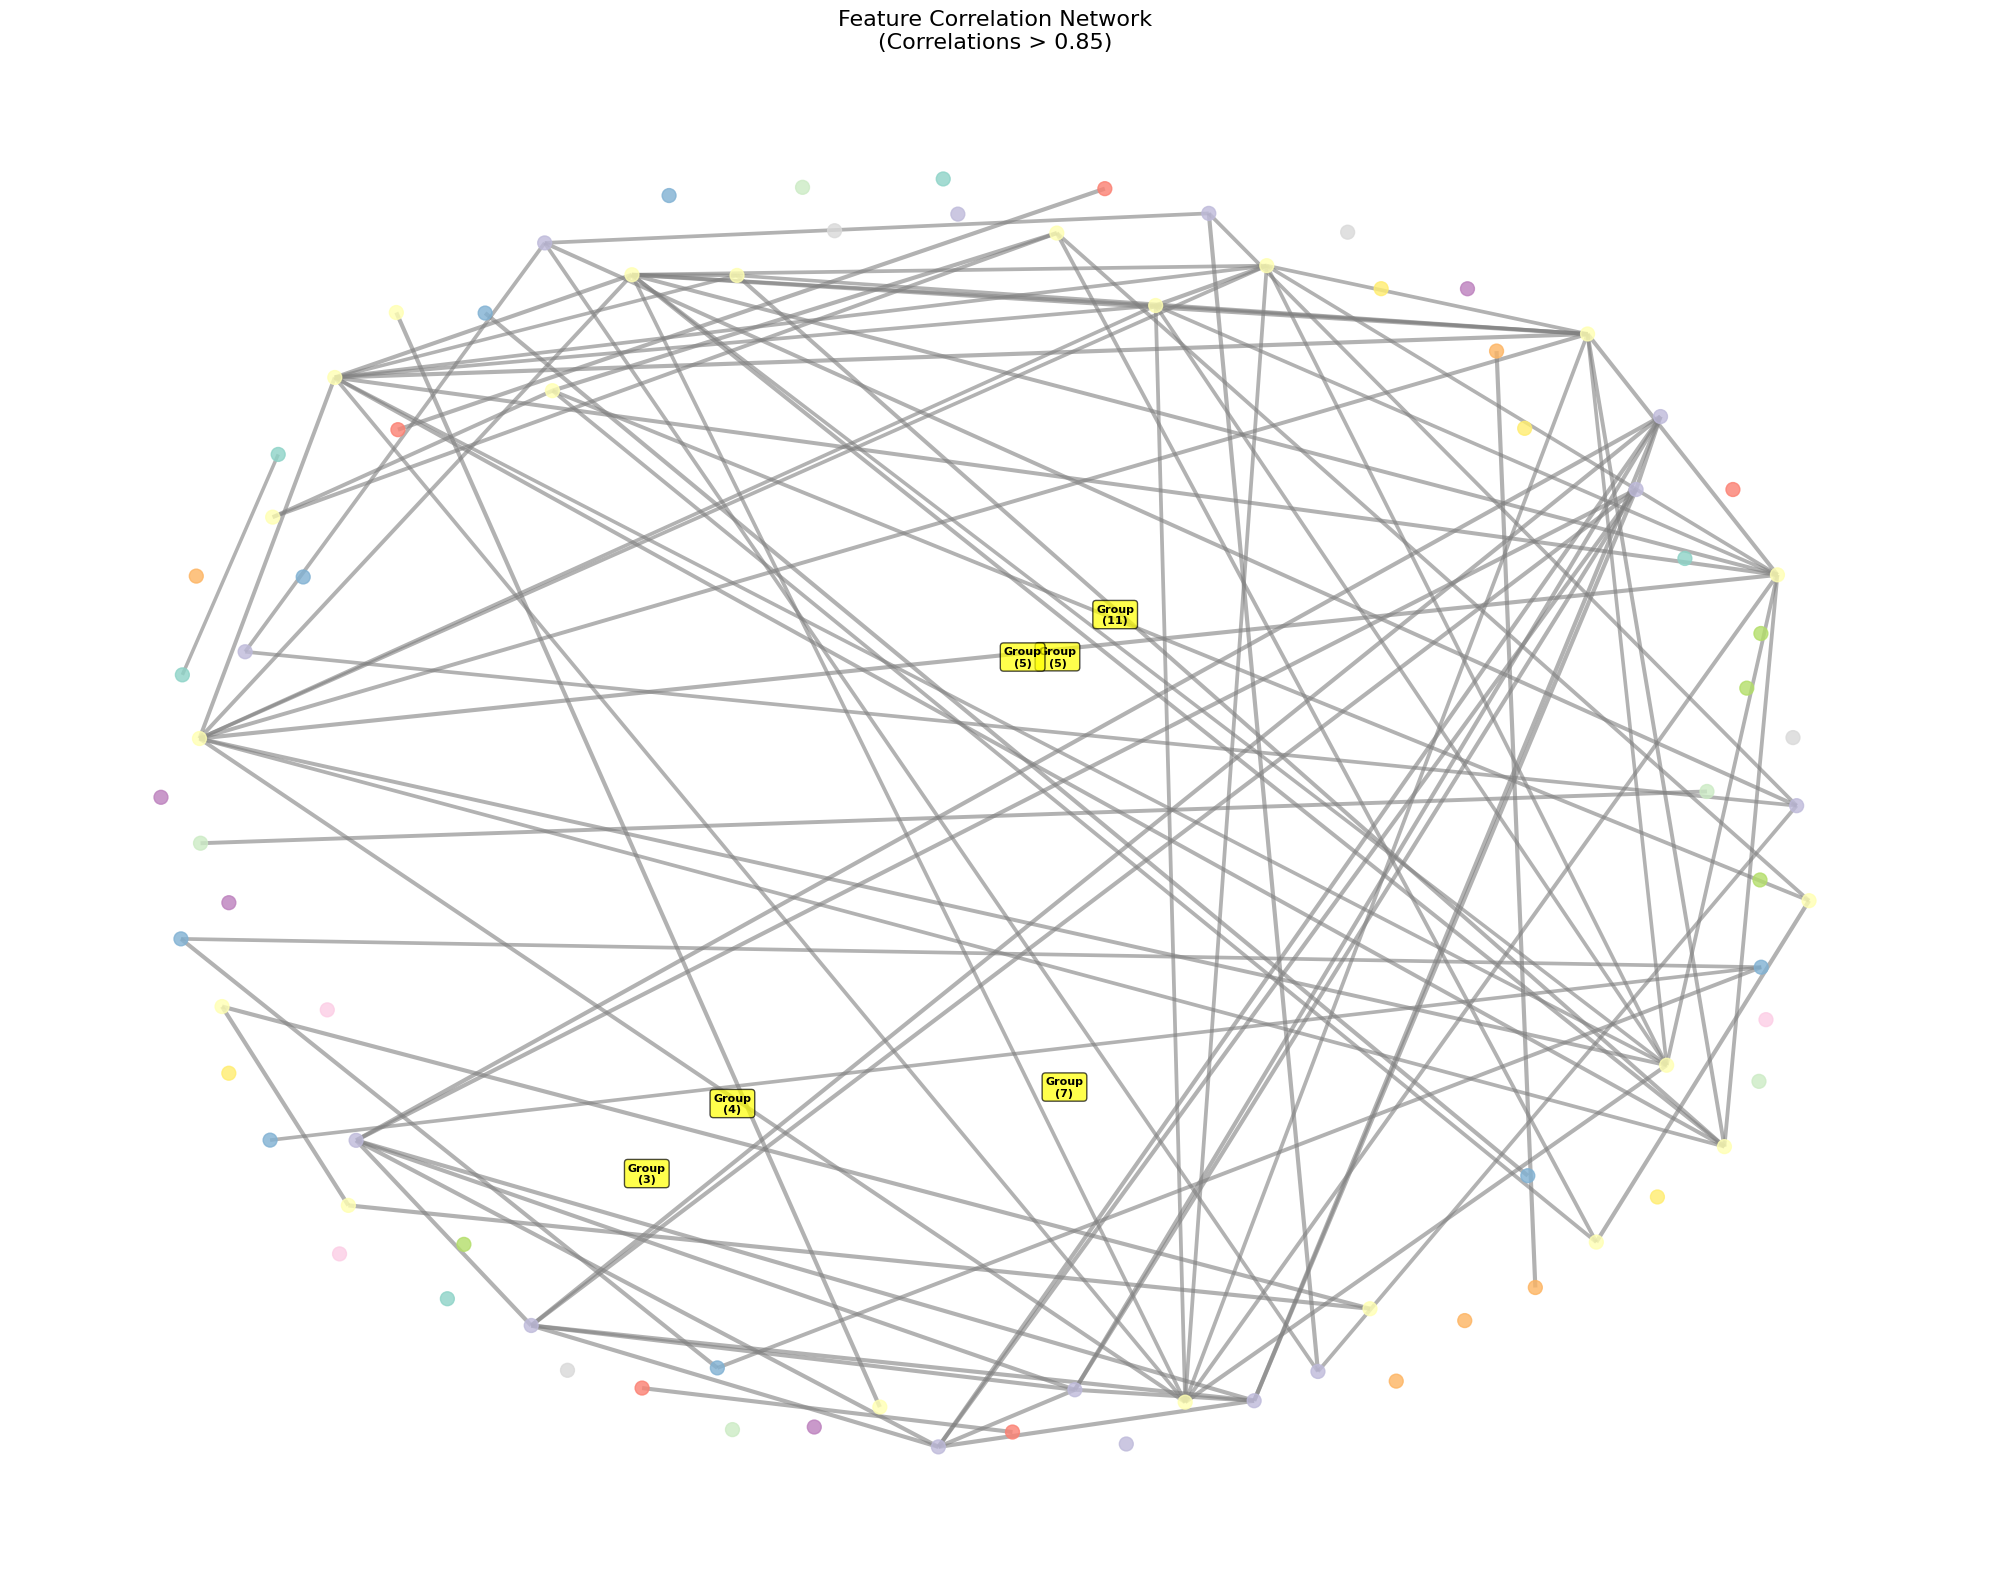

In [20]:
# Visualize correlation network
plt.figure(figsize=(20, 16))

# Create layout
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Draw nodes
node_colors = []
for node in G.nodes():
    # Color nodes by which group they belong to
    for i, component in enumerate(connected_components):
        if node in component:
            node_colors.append(i)
            break
    else:
        node_colors.append(-1)  # Singleton nodes

nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors,
                       node_size=100,
                       cmap=plt.cm.Set3,
                       alpha=0.8)

# Draw edges with thickness based on correlation strength
edges = G.edges()
edge_weights = [G[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G, pos,
                       width=[w*3 for w in edge_weights],
                       alpha=0.6,
                       edge_color='gray')

# Add labels for larger components only
for component in connected_components:
    if len(component) > 2:  # Only label groups with 3+ features
        # Find center of component
        component_pos = {node: pos[node] for node in component}
        center_x = np.mean([pos[0] for pos in component_pos.values()])
        center_y = np.mean([pos[1] for pos in component_pos.values()])
        plt.text(center_x, center_y, f'Group\n({len(component)})',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                fontsize=8, fontweight='bold')

plt.title(f'Feature Correlation Network\n(Correlations > {correlation_threshold})', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('correlation_network.png', dpi=300, bbox_inches='tight')
plt.show()

### Create Dendrogram

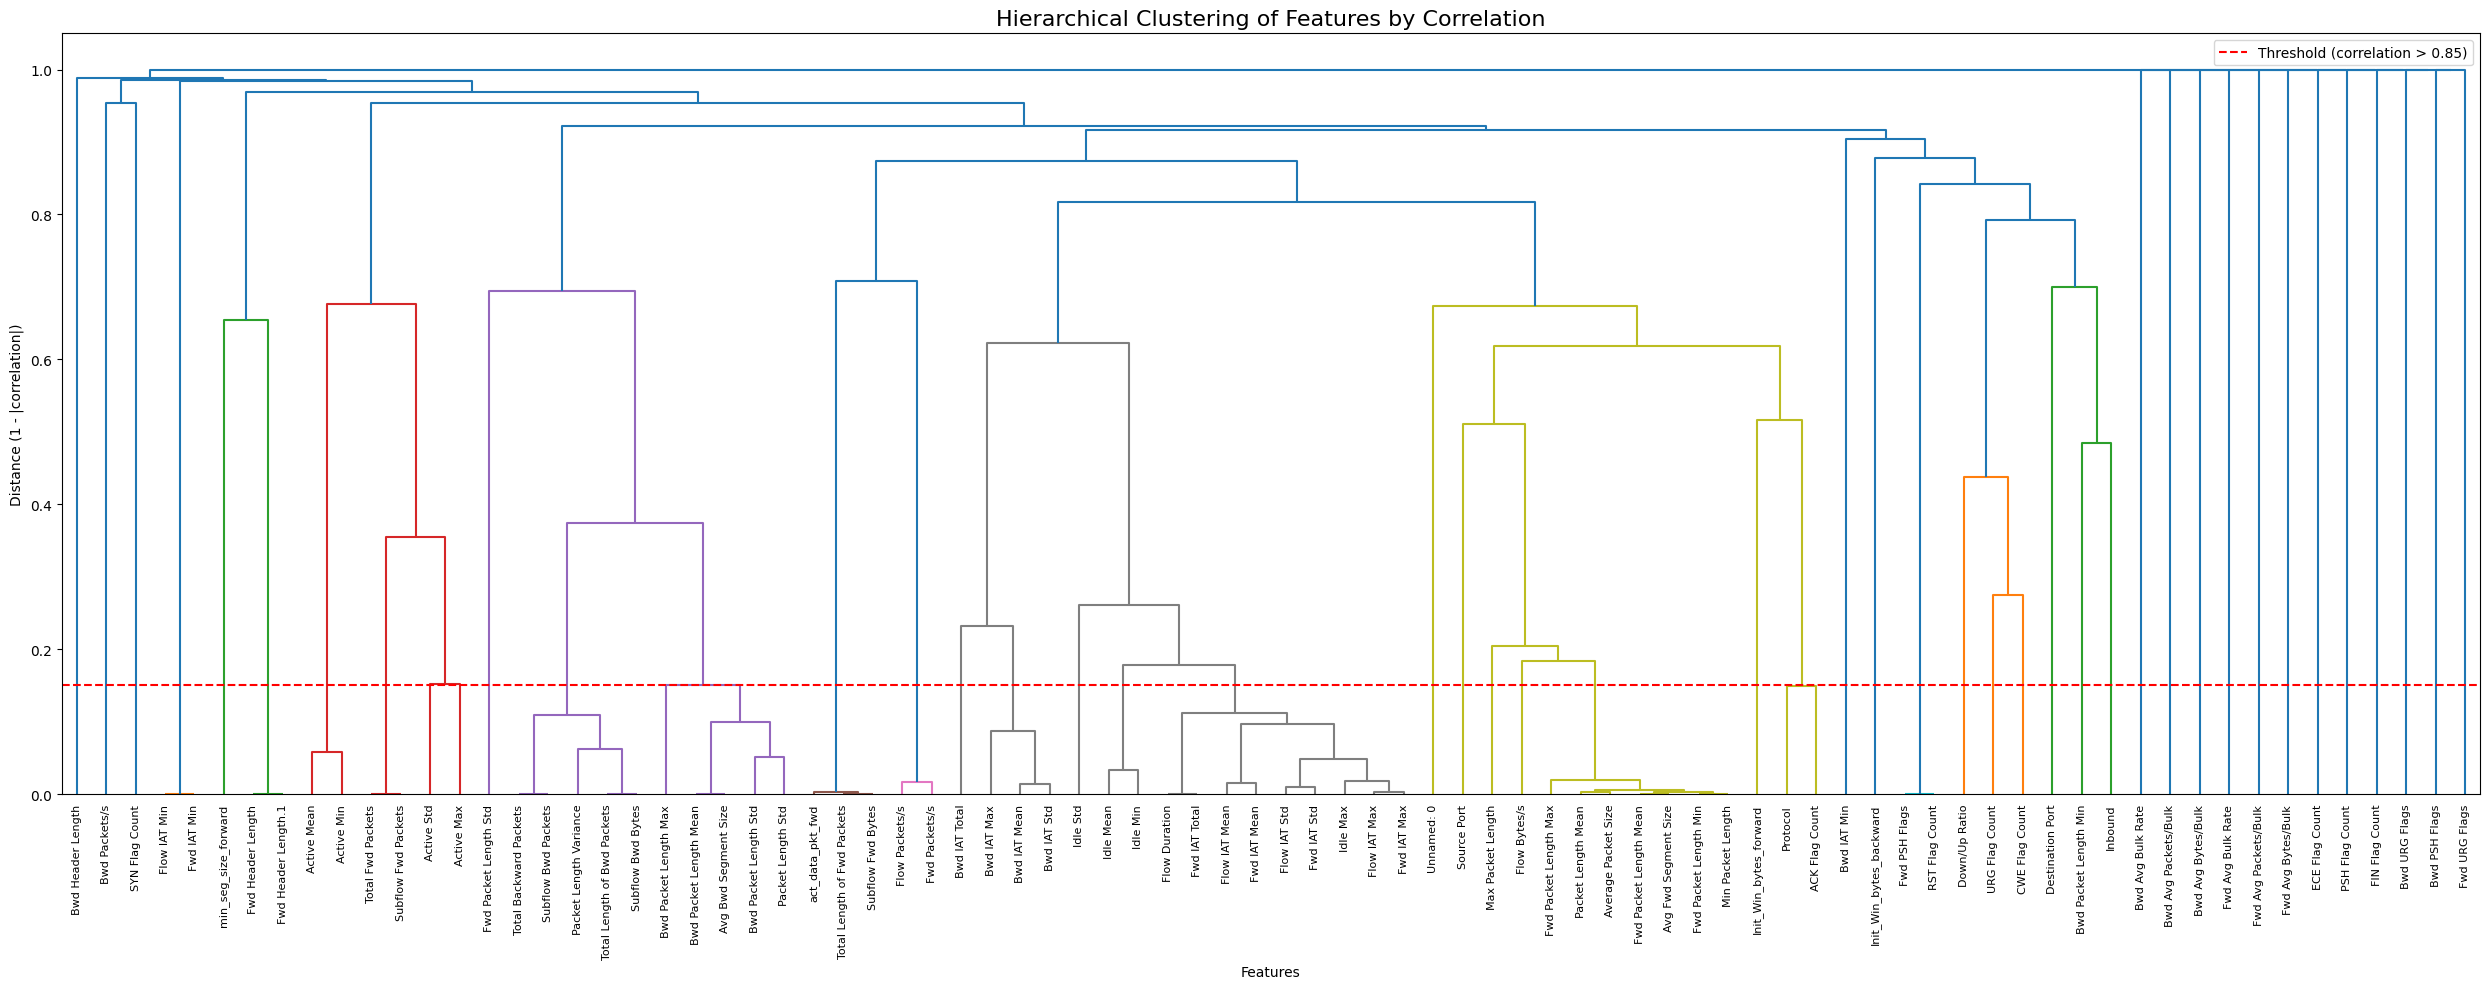

In [21]:
# Create dendrogram for hierarchical clustering
plt.figure(figsize=(25, 10))
dendrogram(linkage_matrix,
           labels=correlation_matrix.index,
           orientation='top',
           leaf_rotation=90,
           leaf_font_size=8)

# Add horizontal line at threshold
plt.axhline(y=distance_threshold, color='r', linestyle='--',
            label=f'Threshold (correlation > {correlation_threshold})')
plt.xlabel('Features')
plt.ylabel('Distance (1 - |correlation|)')
plt.title('Hierarchical Clustering of Features by Correlation', fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig('correlation_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

### Save Results to Files

In [22]:
# Save correlation groups to files
print(f"\n💾 Saving correlation analysis results...")

# 1. Save all correlation pairs
high_corr_df.to_csv('high_correlation_pairs.csv', index=False)

# 2. Save correlation groups
groups_df_data = []
for group_info in groups_analysis:
    for feature in group_info['features']:
        groups_df_data.append({
            'group_name': group_info['group_name'],
            'feature': feature,
            'group_size': group_info['feature_count'],
            'avg_group_correlation': group_info['avg_correlation'],
            'min_group_correlation': group_info['min_correlation'],
            'max_group_correlation': group_info['max_correlation']
        })

correlation_groups_df = pd.DataFrame(groups_df_data)
correlation_groups_df.to_csv('correlation_groups.csv', index=False)

# 3. Save singleton features (no correlations)
singleton_df = pd.DataFrame({'feature': singleton_features, 'status': 'no_high_correlations'})
singleton_df.to_csv('singleton_features.csv', index=False)

# 4. Save full correlation matrix
correlation_matrix.to_csv('full_correlation_matrix.csv')

# 5. Create summary report
summary_data = {
    'total_features': len(feature_columns),
    'correlation_threshold': correlation_threshold,
    'highly_correlated_pairs': len(high_corr_pairs),
    'correlation_groups': len(correlation_groups),
    'features_in_groups': sum(len(features) for features in correlation_groups.values()),
    'singleton_features': len(singleton_features),
    'largest_group_size': max(len(features) for features in correlation_groups.values()) if correlation_groups else 0
}

with open('correlation_analysis_summary.txt', 'w') as f:
    f.write("CORRELATION ANALYSIS SUMMARY\n")
    f.write("="*50 + "\n\n")
    for key, value in summary_data.items():
        f.write(f"{key.replace('_', ' ').title()}: {value}\n")

    f.write(f"\nCORRELATION GROUPS DETAILS:\n")
    f.write("-"*30 + "\n")
    for group_info in groups_analysis:
        f.write(f"\n{group_info['group_name']}: {group_info['feature_count']} features\n")
        f.write(f"  Average correlation: {group_info['avg_correlation']:.3f}\n")
        f.write(f"  Features: {', '.join(group_info['features'])}\n")

print(f"✅ Analysis complete! Files saved:")
print(f"   • high_correlation_pairs.csv")
print(f"   • correlation_groups.csv")
print(f"   • singleton_features.csv")
print(f"   • full_correlation_matrix.csv")
print(f"   • correlation_analysis_summary.txt")
print(f"   • correlation_matrix_heatmap.png")
print(f"   • correlation_network.png")
print(f"   • correlation_dendrogram.png")


💾 Saving correlation analysis results...
✅ Analysis complete! Files saved:
   • high_correlation_pairs.csv
   • correlation_groups.csv
   • singleton_features.csv
   • full_correlation_matrix.csv
   • correlation_analysis_summary.txt
   • correlation_matrix_heatmap.png
   • correlation_network.png
   • correlation_dendrogram.png


### Final Summary Display

In [24]:
# Final summary display
print(f"\n{'='*80}")
print("FINAL CORRELATION ANALYSIS SUMMARY")
print(f"{'='*80}")

print(f"  DATASET OVERVIEW:")
print(f"   • Total features analyzed: {len(feature_columns)}")
print(f"   • Correlation threshold: {correlation_threshold}")
print(f"   • Dataset size: {df.shape[0]:,} rows")

print(f"\n  CORRELATION FINDINGS:")
print(f"   • Highly correlated pairs found: {len(high_corr_pairs)}")
print(f"   • Correlation groups identified: {len(correlation_groups)}")
print(f"   • Features involved in groups: {sum(len(features) for features in correlation_groups.values())}")
print(f"   • Singleton features (no high correlations): {len(singleton_features)}")

if correlation_groups:
    print(f"   • Largest correlation group: {max(len(features) for features in correlation_groups.values())} features")
    print(f"   • Average group size: {np.mean([len(features) for features in correlation_groups.values()]):.1f} features")


FINAL CORRELATION ANALYSIS SUMMARY
  DATASET OVERVIEW:
   • Total features analyzed: 82
   • Correlation threshold: 0.85
   • Dataset size: 144,000 rows

  CORRELATION FINDINGS:
   • Highly correlated pairs found: 96
   • Correlation groups identified: 14
   • Features involved in groups: 47
   • Singleton features (no high correlations): 35
   • Largest correlation group: 9 features
   • Average group size: 3.4 features
